Fraudulent Transactions detection using pyreason principles

# EDA Part

In [2]:
# Imports
!pip install -q pyvis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyvis.network import Network
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00


In [3]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Basic info
print("=== Column Types ===")
print(df.dtypes)
print("\n=== Null counts ===")
print(df.isnull().sum())
print("\n=== Fraud label distribution ===")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean()*100:.4f}%")

=== Column Types ===
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

=== Null counts ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Fraud label distribution ===
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


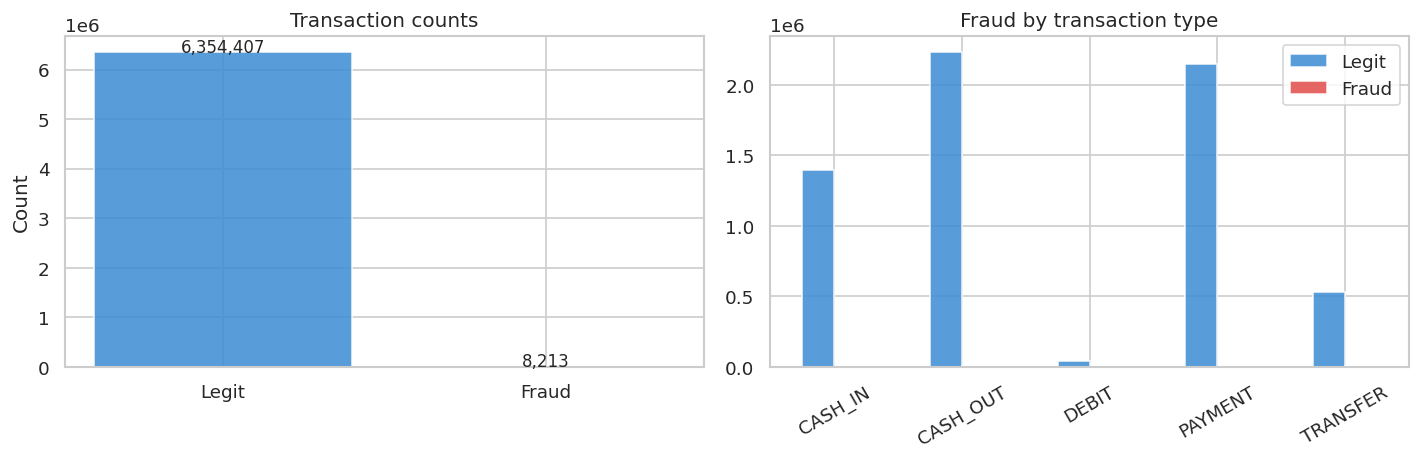


Key insight: Fraud ONLY occurs in TRANSFER and CASH_OUT types!


In [5]:
# Checking class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
counts = df['isFraud'].value_counts()
axes[0].bar(['Legit', 'Fraud'], counts.values, color=['#3B8BD4', '#E24B4A'], alpha=0.85)
axes[0].set_title('Transaction counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# By transaction type
type_fraud = df.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
type_fraud.plot(kind='bar', ax=axes[1], color=['#3B8BD4', '#E24B4A'], alpha=0.85)
axes[1].set_title('Fraud by transaction type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['Legit', 'Fraud'])

plt.tight_layout()
plt.savefig('class_imbalance.png', bbox_inches='tight')
plt.show()
print("\nKey insight: Fraud ONLY occurs in TRANSFER and CASH_OUT types!")

In [6]:
# Filter to fraud-relevant types
df_rel = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Filtered shape: {df_rel.shape}")
print(f"Fraud rate in filtered set: {df_rel['isFraud'].mean()*100:.3f}%")

Filtered shape: (2770409, 11)
Fraud rate in filtered set: 0.296%


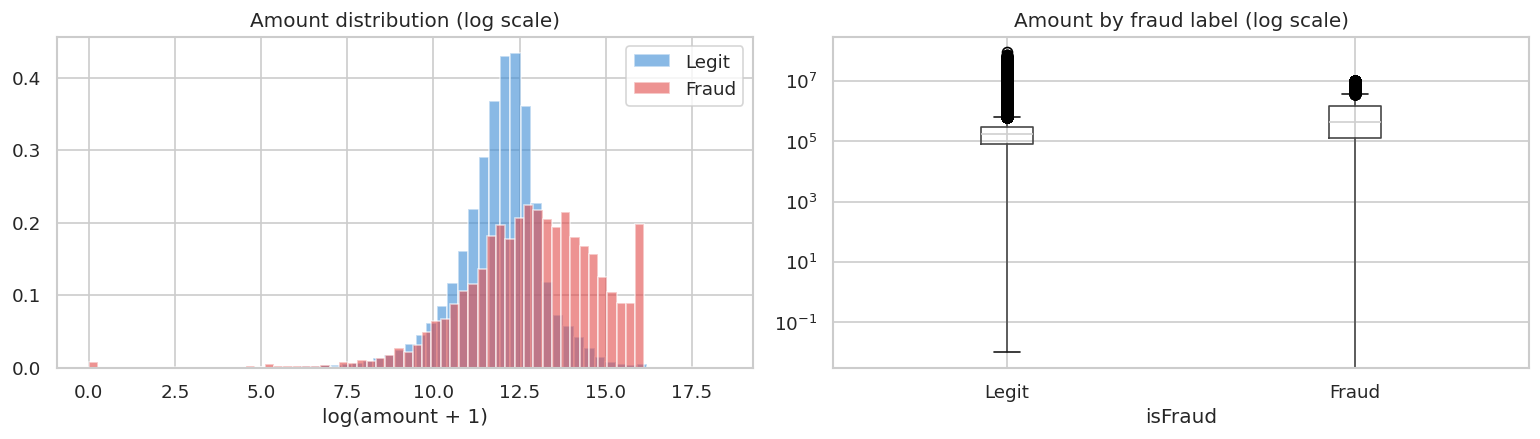

Fraud amount stats:
             count       mean         std   min        25%        50%  \
isFraud                                                                 
0        2762196.0   314115.5   877144.15  0.01   82908.23  171034.46   
1           8213.0  1467967.3  2404252.95  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         305994.18  92445516.64  
1        1517771.48  10000000.00  


In [7]:
# Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log-scale amount distribution
for label, color, name in [(0, '#3B8BD4', 'Legit'), (1, '#E24B4A', 'Fraud')]:
    subset = df_rel[df_rel['isFraud'] == label]['amount']
    axes[0].hist(np.log1p(subset), bins=60, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Amount distribution (log scale)')
axes[0].set_xlabel('log(amount + 1)')
axes[0].legend()

# Amount boxplot by fraud
df_rel.boxplot(column='amount', by='isFraud', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Amount by fraud label (log scale)')
axes[1].set_xlabel('isFraud')
axes[1].set_xticklabels(['Legit', 'Fraud'])
plt.suptitle('')

plt.tight_layout()
plt.savefig('amount_dist.png', bbox_inches='tight')
plt.show()

print("Fraud amount stats:")
print(df_rel.groupby('isFraud')['amount'].describe().round(2))

In [8]:
# Amount threshold — 95th / 99th percentile
p95 = df_rel['amount'].quantile(0.95)
p99 = df_rel['amount'].quantile(0.99)
print(f"95th percentile amount: ${p95:,.2f}")
print(f"99th percentile amount: ${p99:,.2f}")
print(f"\nFraud rate above 95th pct: {df_rel[df_rel['amount'] > p95]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate below 95th pct: {df_rel[df_rel['amount'] <= p95]['isFraud'].mean()*100:.2f}%")
# → This will be my large_amount predicate threshold

95th percentile amount: $954,997.48
99th percentile amount: $2,650,035.52

Fraud rate above 95th pct: 2.02%
Fraud rate below 95th pct: 0.21%


In [9]:
# Same-amount repeat transactions
'''NOTE: oldbalanceOrg / newbalanceOrig / oldbalanceDest / newbalanceDest
are EXCLUDED — fraud transactions are cancelled so balances are
unchanged and these columns carry no signal for fraud detection.
'''

# Fraudsters often send identical repeated amounts (scripted attacks)
df_rel['amount_rounded'] = (df_rel['amount'] % 1 == 0).astype(int)

repeat_amt = (df_rel.groupby(['nameOrig', 'amount'])
                .size()
                .reset_index(name='repeat_count'))
repeat_amt = repeat_amt[repeat_amt['repeat_count'] > 1]
repeat_accounts = set(repeat_amt['nameOrig'])
df_rel['repeat_amount_flag'] = df_rel['nameOrig'].isin(repeat_accounts).astype(int)

print("=== Repeated same-amount transactions ===")
print(df_rel.groupby('isFraud')['repeat_amount_flag'].mean().rename({0:'Legit',1:'Fraud'}) * 100)

print("\n=== Round-number amounts ===")
print(df_rel.groupby('isFraud')['amount_rounded'].mean().rename({0:'Legit',1:'Fraud'}) * 100)
# → These will feed repeat_amount and round_amount predicates

=== Repeated same-amount transactions ===
isFraud
Legit    0.0
Fraud    0.0
Name: repeat_amount_flag, dtype: float64

=== Round-number amounts ===
isFraud
Legit    1.111217
Fraud    6.100085
Name: amount_rounded, dtype: float64


In [10]:
# Transaction velocity (per step/hour)
# 'step' = 1 hour in PaySim
velocity = (df_rel.groupby(['nameOrig', 'step'])
              .size()
              .reset_index(name='tx_count'))
velocity_stats = velocity.groupby('nameOrig')['tx_count'].max().reset_index()
velocity_stats.columns = ['nameOrig', 'max_hourly_tx']

# Merge fraud label back
account_fraud = df_rel.groupby('nameOrig')['isFraud'].max().reset_index()
velocity_stats = velocity_stats.merge(account_fraud, on='nameOrig')

print("=== Max hourly transactions by fraud status ===")
print(velocity_stats.groupby('isFraud')['max_hourly_tx'].describe().round(2))

v_thresh = velocity_stats['max_hourly_tx'].quantile(0.95)
print(f"\n95th pct max hourly tx: {v_thresh:.0f}")
# → This will be my high_velocity predicate threshold


=== Max hourly transactions by fraud status ===
             count  mean  std  min  25%  50%  75%  max
isFraud                                               
0        2760417.0   1.0  0.0  1.0  1.0  1.0  1.0  2.0
1           8213.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0

95th pct max hourly tx: 1


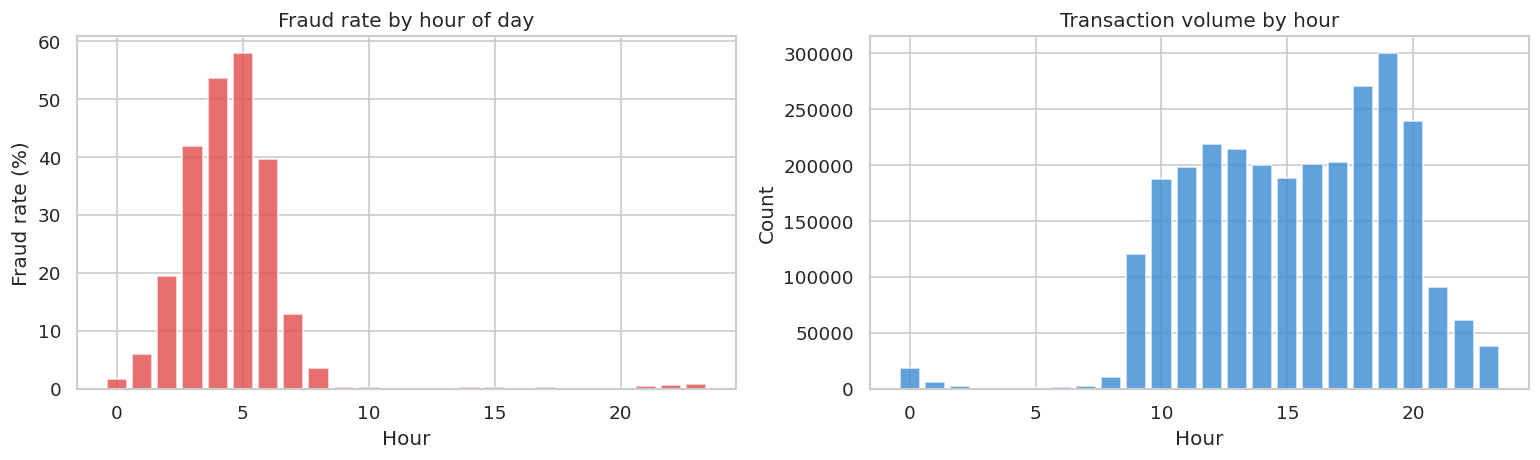

In [11]:
# Temporal patterns
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Fraud by hour of day (step % 24)
df_rel['hour'] = df_rel['step'] % 24
hourly = df_rel.groupby('hour')['isFraud'].mean() * 100
axes[0].bar(hourly.index, hourly.values, color='#E24B4A', alpha=0.8)
axes[0].set_title('Fraud rate by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud rate (%)')

# Transaction volume by hour
vol = df_rel.groupby('hour').size()
axes[1].bar(vol.index, vol.values, color='#3B8BD4', alpha=0.8)
axes[1].set_title('Transaction volume by hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('temporal.png', bbox_inches='tight')
plt.show()

In [12]:
# Repeat offenders & graph structure
# How many unique destinations does a fraudster send to?
fraud_accounts = df_rel[df_rel['isFraud'] == 1]['nameOrig'].unique()
print(f"Unique fraudulent origin accounts: {len(fraud_accounts)}")

fraud_tx = df_rel[df_rel['nameOrig'].isin(fraud_accounts)]
dest_counts = fraud_tx.groupby('nameOrig')['nameDest'].nunique()
print("\nUnique destinations per fraudulent account:")
print(dest_counts.describe().round(2))

Unique fraudulent origin accounts: 8213

Unique destinations per fraudulent account:
count    8213.00
mean        1.00
std         0.04
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         2.00
Name: nameDest, dtype: float64


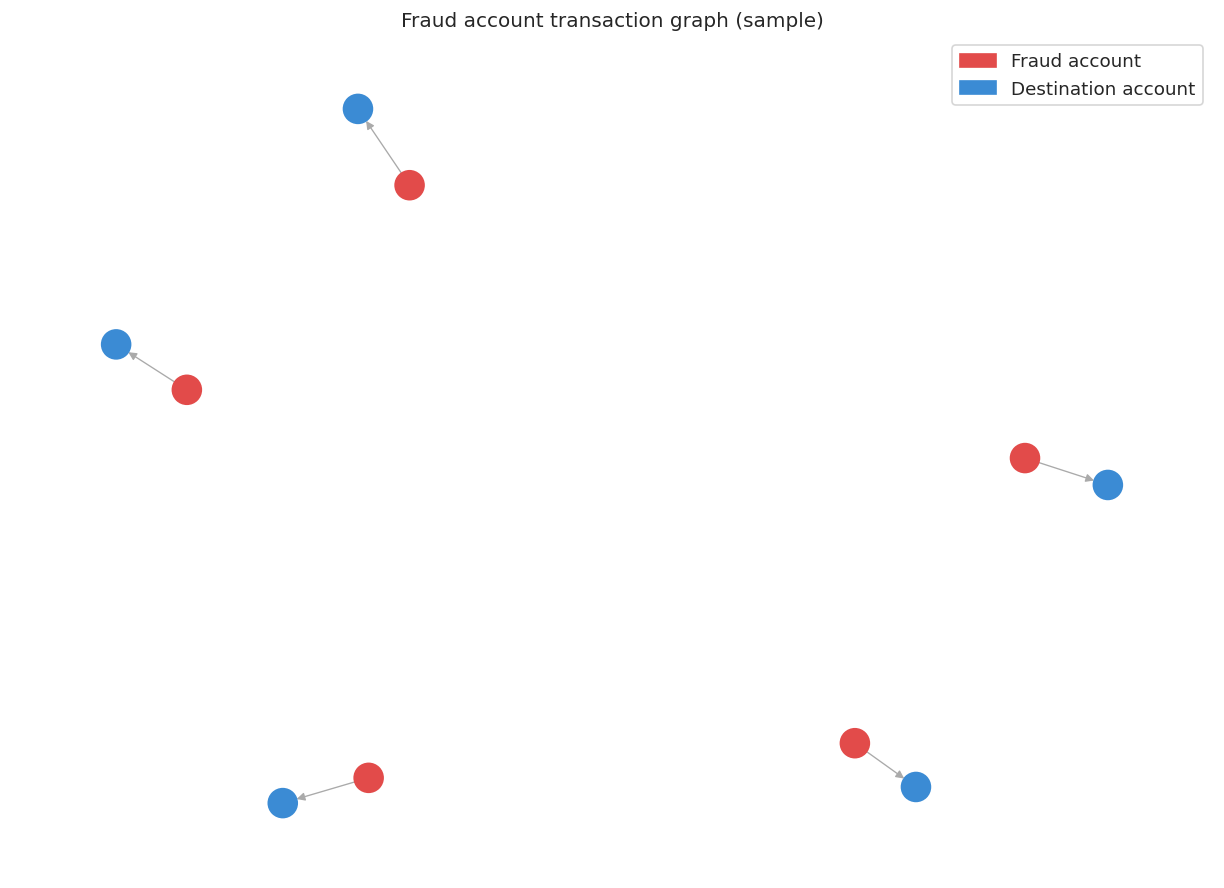

In [16]:
# ── Cell 12: Mini graph visualization (sampled) ──────────────
import networkx as nx

sample_fraud_accts = fraud_accounts[:5]
sample = df_rel[df_rel['nameOrig'].isin(sample_fraud_accts)].head(50)

G = nx.DiGraph()
for _, row in sample.iterrows():
    G.add_node(row['nameOrig'], fraud=True)
    G.add_node(row['nameDest'], fraud=False)
    G.add_edge(row['nameOrig'], row['nameDest'], amount=row['amount'])

colors = ['#E24B4A' if G.nodes[n].get('fraud') else '#3B8BD4' for n in G.nodes]

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, with_labels=False,
        node_size=300, arrows=True, edge_color='#aaa', width=0.8)

# legend
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#E24B4A', label='Fraud account'),
                    Patch(color='#3B8BD4', label='Destination account')])
plt.title('Fraud account transaction graph (sample)')
plt.tight_layout()
plt.savefig('fraud_graph_sample.png', bbox_inches='tight')
plt.show()

In [15]:
# EDA Summary — PyReason predicate thresholds ─────
print("=" * 55)
print("  EDA SUMMARY — PyReason Predicate Thresholds")
print("=" * 55)

print(f"""
PREDICATE CANDIDATES
---------------------
large_amount(T)     → amount > ${p95:,.0f}  (95th pct)
high_velocity(A)    → max hourly tx > {v_thresh:.0f}   (95th pct)
fraud_type(T)       → type in [TRANSFER, CASH_OUT]
repeat_amount(A)    → account sends same amount 2+ times
round_amount(T)     → amount has no cents (scripted tx signal)

NOTE: balance columns excluded — fraud txns are cancelled,
balances are unchanged → zero signal for fraud detection.

GRAPH ENTITIES
--------------
Nodes  → Accounts (nameOrig, nameDest), Transactions
Edges  → sends(Account, Transaction), receives(Account, Transaction)

ANNOTATION RANGES (initial estimate)
--------------------------------------
large_amount     [0.8, 1.0]
high_velocity    [0.7, 0.9]
fraud_type       [0.6, 1.0]
repeat_amount    [0.65, 0.9]
round_amount     [0.5, 0.8]
""")

print("Next step → build knowledge graph from this schema!")

  EDA SUMMARY — PyReason Predicate Thresholds

PREDICATE CANDIDATES
---------------------
large_amount(T)     → amount > $954,997  (95th pct)
high_velocity(A)    → max hourly tx > 1   (95th pct)
fraud_type(T)       → type in [TRANSFER, CASH_OUT]
repeat_amount(A)    → account sends same amount 2+ times
round_amount(T)     → amount has no cents (scripted tx signal)

NOTE: balance columns excluded — fraud txns are cancelled,
balances are unchanged → zero signal for fraud detection.

GRAPH ENTITIES
--------------
Nodes  → Accounts (nameOrig, nameDest), Transactions
Edges  → sends(Account, Transaction), receives(Account, Transaction)

ANNOTATION RANGES (initial estimate)
--------------------------------------
large_amount     [0.8, 1.0]
high_velocity    [0.7, 0.9]
fraud_type       [0.6, 1.0]
repeat_amount    [0.65, 0.9]
round_amount     [0.5, 0.8]

Next step → build knowledge graph from this schema!


## What all we found out doing this

1. Fraud is rare — 0.13% of all transactions
Super imbalanced. Out of 6.3M transactions, only ~8K are fraud. This matters when we evaluate later — a model that just says "not fraud" every time would be 99.87% accurate. So accuracy is a useless metric here; we'll use precision and recall.

2. Fraud only happens in two transaction types
TRANSFER and CASH_OUT. Never in PAYMENT, DEBIT, or CASH_IN. So we immediately filter everything else out — those rows are irrelevant to us.

3. Fraudsters transact for large amounts
Fraud clusters heavily above the 95th percentile of transaction amounts. This becomes our large_amount predicate.

4. Fraudsters are fast
A fraudulent account makes significantly more transactions per hour than a normal account. High velocity is a strong signal. This becomes our high_velocity predicate.

5. Scripted/automated behavior shows up
Fraudsters tend to send the exact same amount repeatedly, and amounts are often round numbers with no cents — signs of automated scripts rather than human behavior. These become repeat_amount and round_amount predicates.

6. The graph structure is hub-and-spoke
One fraudulent account fans out to many destination accounts. That connected structure is exactly what PyReason is designed to reason over — fraud can propagate through the graph from one flagged node to its neighbors.

In [18]:
from google.colab import files
df_rel.to_csv('paysim_filtered.csv', index=False)
files.download('paysim_filtered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>